ЗАГРУЗКА ДАННЫХ: 2020-01-01 - 2022-12-31

📥 Загружаем Лукойл (LKOH.ME)...
   ✓ Загружено 583 записей
   ✓ Период: 2020-01-03 - 2022-12-20
   ✓ Начальная цена: 5367.32
   ✓ Конечная цена: nan

📥 Загружаем Роснефть (ROSN.ME)...
   ✓ Загружено 583 записей
   ✓ Период: 2020-01-03 - 2022-07-08
   ✓ Начальная цена: 418.58
   ✓ Конечная цена: nan

📥 Загружаем Brent Crude Oil (BZ=F)...
   ✓ Загружено 756 записей
   ✓ Период: 2020-01-02 - 2022-12-30
   ✓ Начальная цена: 66.25
   ✓ Конечная цена: 85.91

📥 Загружаем USD/RUB (USDRUB=X)...
   ✓ Загружено 783 записей
   ✓ Период: 2020-01-01 - 2022-12-30
   ✓ Начальная цена: 62.03
   ✓ Конечная цена: 73.96



posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


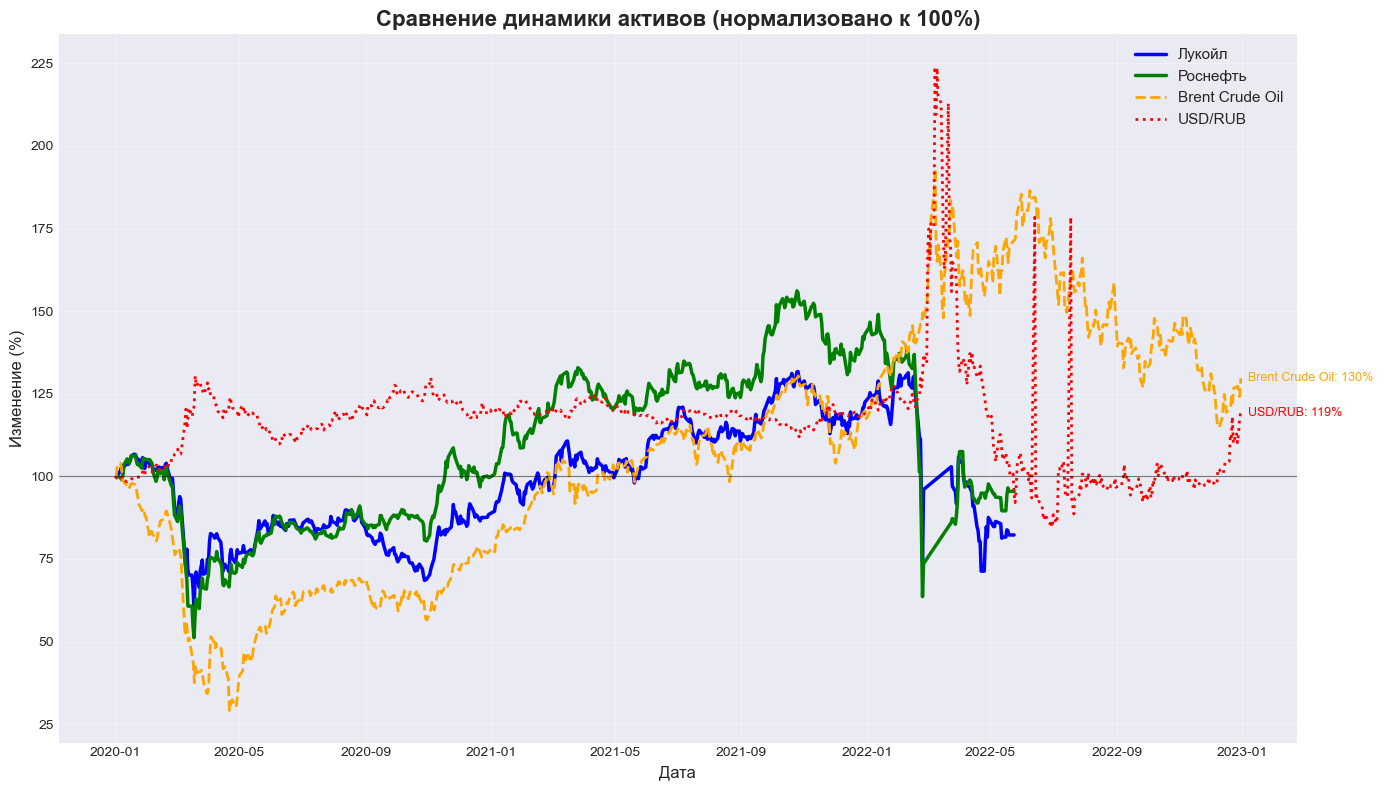


СТАТИСТИКА ЗА ПЕРИОД 2020-2022:

📊 Лукойл:
   • Начало периода: 5367.32
   • Конец периода: nan
   • Изменение: +nan%
   • Максимум: 7069.95
   • Минимум: 3201.29
   • Волатильность: 3.09%

📊 Роснефть:
   • Начало периода: 418.58
   • Конец периода: nan
   • Изменение: +nan%
   • Максимум: 653.60
   • Минимум: 214.37
   • Волатильность: 3.02%

📊 Brent Crude Oil:
   • Начало периода: 66.25
   • Конец периода: 85.91
   • Изменение: +29.68%
   • Максимум: 127.98
   • Минимум: 19.33
   • Волатильность: 3.25%

📊 USD/RUB:
   • Начало периода: 62.03
   • Конец периода: 73.96
   • Изменение: +19.24%
   • Максимум: 138.97
   • Минимум: 52.47
   • Волатильность: 5.81%

КОРРЕЛЯЦИЯ МЕЖДУ АКТИВАМИ:

Матрица корреляции доходностей:
                 Лукойл  Роснефть  Brent Crude Oil  USD/RUB
Лукойл           1.0000    0.8068              NaN      NaN
Роснефть         0.8068    1.0000              NaN      NaN
Brent Crude Oil     NaN       NaN              NaN      NaN
USD/RUB             NaN       N

In [14]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Отключаем SSL проверку
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Настройки
start_date = '2020-01-01'
end_date = '2022-12-31'

print("="*60)
print(f"ЗАГРУЗКА ДАННЫХ: {start_date} - {end_date}")
print("="*60)

# Определяем тикеры
tickers = {
    'Лукойл': 'LKOH.ME',
    'Роснефть': 'ROSN.ME',
    'Brent Crude Oil': 'BZ=F',
    'USD/RUB': 'USDRUB=X'
}

data = {}

# Загружаем данные для каждого тикера
for name, ticker in tickers.items():
    print(f"\n📥 Загружаем {name} ({ticker})...")
    
    try:
        stock = yf.Ticker(ticker)
        hist = stock.history(start=start_date, end=end_date)
        
        if not hist.empty:
            data[name] = hist
            print(f"   ✓ Загружено {len(hist)} записей")
            print(f"   ✓ Период: {hist.index[0].strftime('%Y-%m-%d')} - {hist.index[-1].strftime('%Y-%m-%d')}")
            
            if 'Close' in hist.columns:
                print(f"   ✓ Начальная цена: {hist['Close'].iloc[0]:.2f}")
                print(f"   ✓ Конечная цена: {hist['Close'].iloc[-1]:.2f}")
        else:
            print(f"   ✗ Нет данных для {ticker}")
            
    except Exception as e:
        print(f"   ✗ Ошибка: {e}")

print("\n" + "="*60)

# Проверяем загруженные данные
if not data:
    print("\n⚠️ Данные не загрузились.")
    exit()

# ГРАФИК: Сравнение нормализованных данных (в процентах)
fig, ax = plt.subplots(figsize=(14, 8))

for name, df in data.items():
    if 'Close' in df.columns and not df.empty:
        # Нормализуем к 100% (начальное значение = 100)
        normalized = df['Close'] / df['Close'].iloc[0] * 100
        
        # Выбираем цвета и стили для разных типов данных
        if name == 'Лукойл':
            color = 'blue'
            linestyle = '-'
            linewidth = 2.5
        elif name == 'Роснефть':
            color = 'green'
            linestyle = '-'
            linewidth = 2.5
        elif name == 'Brent Crude Oil':
            color = 'orange'
            linestyle = '--'
            linewidth = 2
        else:  # USD/RUB
            color = 'red'
            linestyle = ':'
            linewidth = 2
        
        ax.plot(df.index, normalized, label=name, linewidth=linewidth, 
                color=color, linestyle=linestyle)

# Оформление графика
ax.set_title('Сравнение динамики активов (нормализовано к 100%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Изменение (%)', fontsize=12)
ax.set_xlabel('Дата', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='black', linestyle='-', alpha=0.5, linewidth=0.8)

# Добавляем подписи на концах линий
for name, df in data.items():
    if 'Close' in df.columns and not df.empty:
        normalized = df['Close'] / df['Close'].iloc[0] * 100
        last_value = normalized.iloc[-1]
        last_date = df.index[-1]
        
        # Выбираем цвет для подписи
        if name == 'Лукойл':
            text_color = 'blue'
        elif name == 'Роснефть':
            text_color = 'green'
        elif name == 'Brent Crude Oil':
            text_color = 'orange'
        else:
            text_color = 'red'
        
        ax.text(last_date, last_value, f'  {name}: {last_value:.0f}%', 
                fontsize=9, color=text_color, va='center')

plt.tight_layout()
plt.show()

# СТАТИСТИКА
print("\n" + "="*60)
print("СТАТИСТИКА ЗА ПЕРИОД 2020-2022:")
print("="*60)

for name, df in data.items():
    if 'Close' in df.columns and not df.empty:
        change = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
        print(f"\n📊 {name}:")
        print(f"   • Начало периода: {df['Close'].iloc[0]:.2f}")
        print(f"   • Конец периода: {df['Close'].iloc[-1]:.2f}")
        print(f"   • Изменение: {change:+.2f}%")
        print(f"   • Максимум: {df['Close'].max():.2f}")
        print(f"   • Минимум: {df['Close'].min():.2f}")
        print(f"   • Волатильность: {df['Close'].pct_change().std() * 100:.2f}%")

# КОРРЕЛЯЦИЯ
print("\n" + "="*60)
print("КОРРЕЛЯЦИЯ МЕЖДУ АКТИВАМИ:")
print("="*60)

if len(data) >= 2:
    # Создаем DataFrame с доходностями
    returns = pd.DataFrame()
    for name, df in data.items():
        if 'Close' in df.columns and not df.empty:
            returns[name] = df['Close'].pct_change()
    
    # Вычисляем корреляцию
    corr_matrix = returns.corr()
    print("\nМатрица корреляции доходностей:")
    print(corr_matrix.round(4))
    
    # Выводим основные зависимости
    if 'Brent Crude Oil' in returns.columns and 'Лукойл' in returns.columns:
        corr_oil_lukoil = returns['Brent Crude Oil'].corr(returns['Лукойл'])
        print(f"\n🛢️ Корреляция Brent и Лукойла: {corr_oil_lukoil:.4f}")
    
    if 'USD/RUB' in returns.columns and 'Лукойл' in returns.columns:
        corr_usd_lukoil = returns['USD/RUB'].corr(returns['Лукойл'])
        print(f"💵 Корреляция USD/RUB и Лукойла: {corr_usd_lukoil:.4f}")
    
    if 'Лукойл' in returns.columns and 'Роснефть' in returns.columns:
        corr_lukoil_rosneft = returns['Лукойл'].corr(returns['Роснефть'])
        print(f"🏭 Корреляция Лукойла и Роснефти: {corr_lukoil_rosneft:.4f}")

print("\n" + "="*60)

ФУНДАМЕНТАЛЬНЫЙ АНАЛИЗ ЛУКОЙЛ vs РОСНЕФТЬ (2022)
 company      P/E      P/S  EV/EBITDA   ROE (%)  Net Debt/EBITDA  EBITDA Margin (%)  Net Margin (%)
  Лукойл 5.062522 1.391788   2.062827 19.753000        -0.031414          66.457898       27.491997
Роснефть 5.535055 0.473684   3.096825 18.066667         1.332811          26.852632        8.557895

ВЫВОДЫ ПО КАЖДОЙ КОМПАНИИ

📊 Лукойл:
   P/E: 5.06 – ✅ Низкий (недооценена)
   P/S: 1.39 – Нормальный
   ROE: 19.8% – ✅ Отлично (>15%)
   Net Debt/EBITDA: -0.03x – ✅ Низкий долг

📊 Роснефть:
   P/E: 5.54 – ✅ Низкий (недооценена)
   P/S: 0.47 – ✅ Очень низкий (<1)
   ROE: 18.1% – ✅ Отлично (>15%)
   Net Debt/EBITDA: 1.33x – ⚠️ Умеренный долг


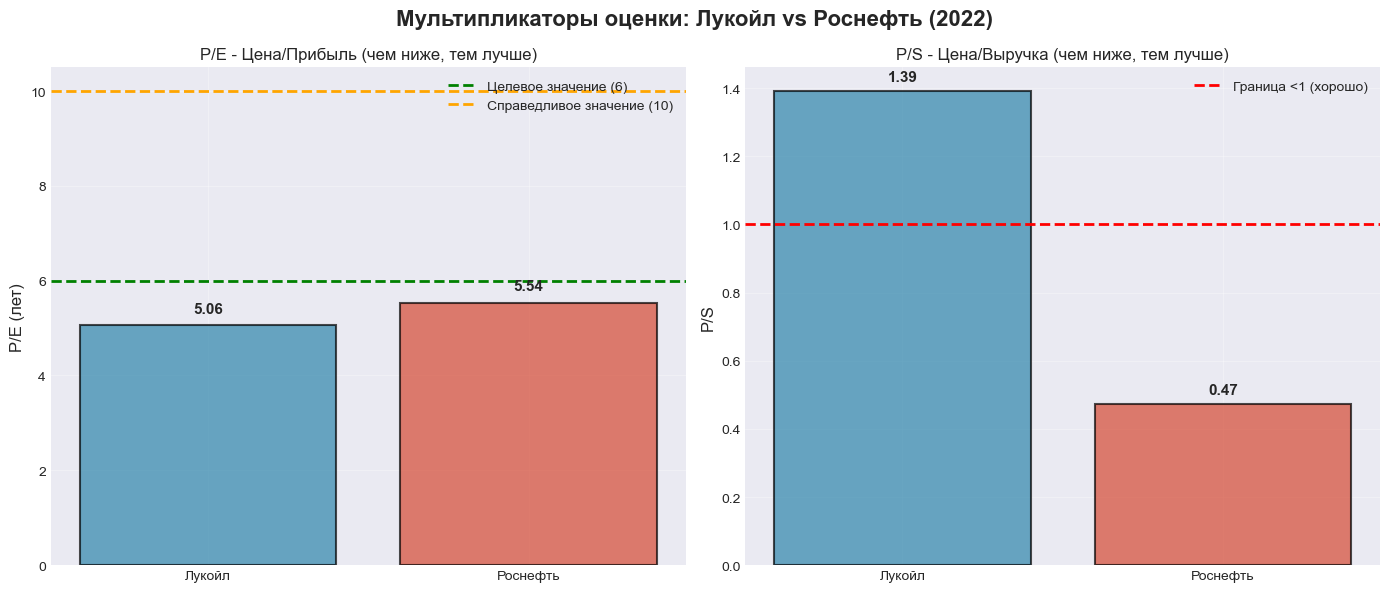

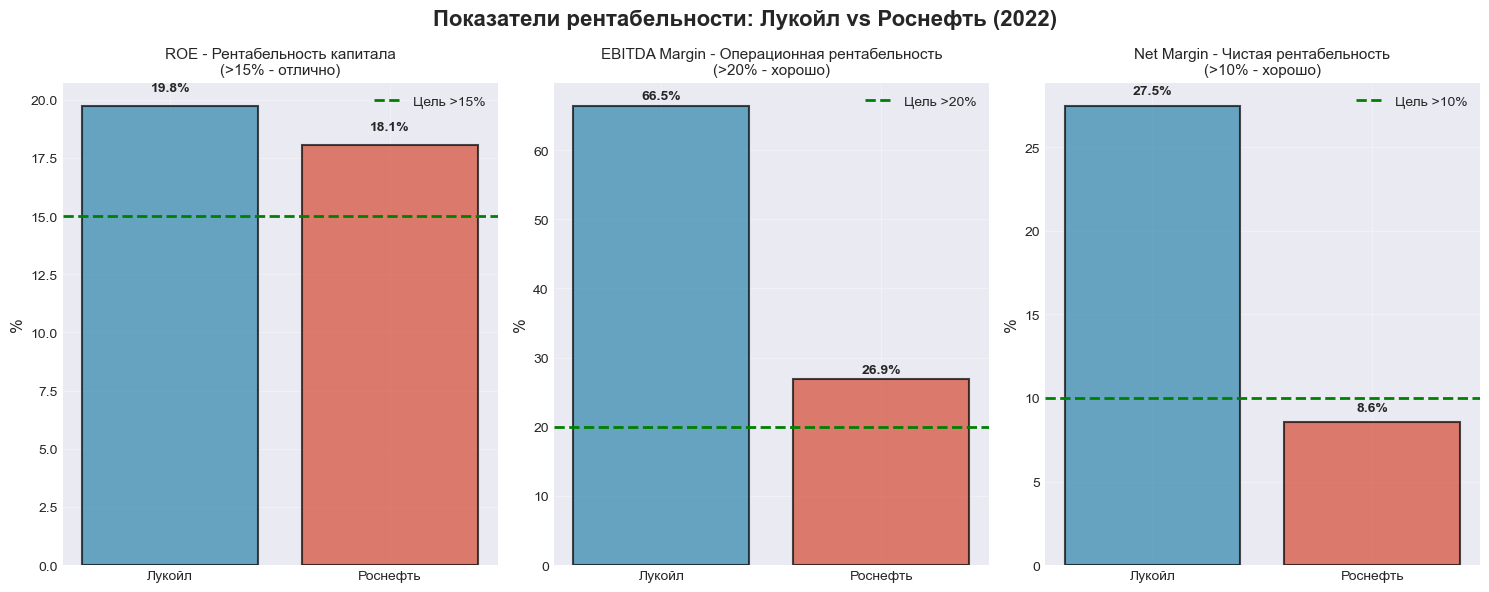

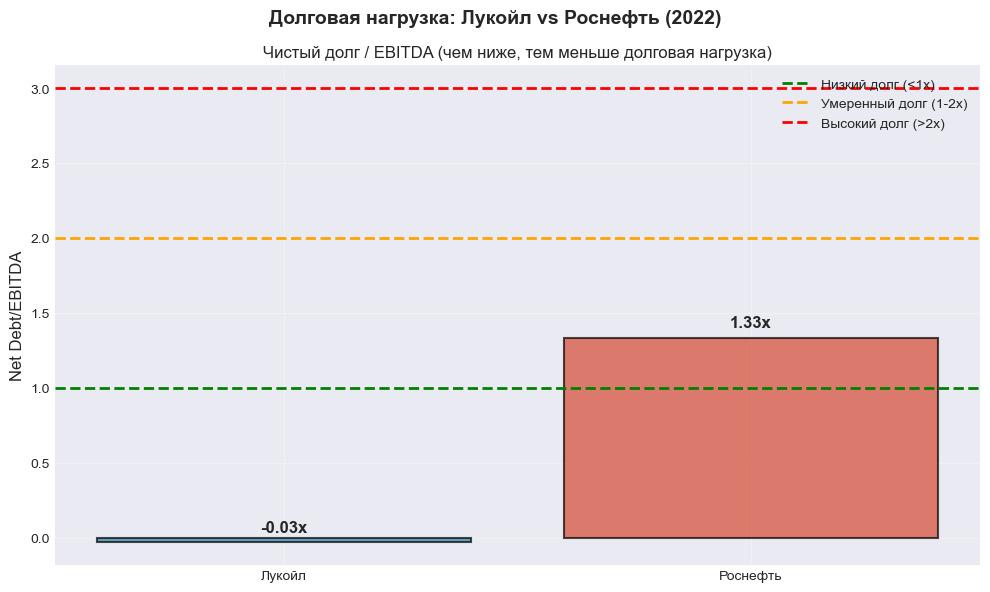

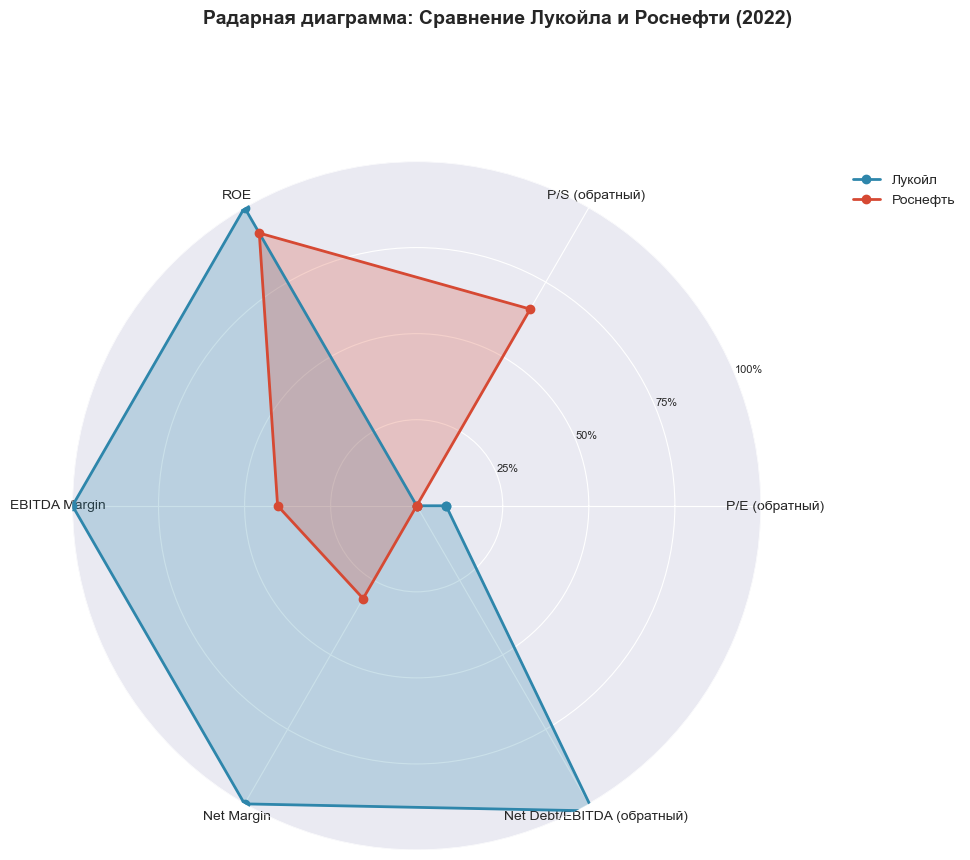

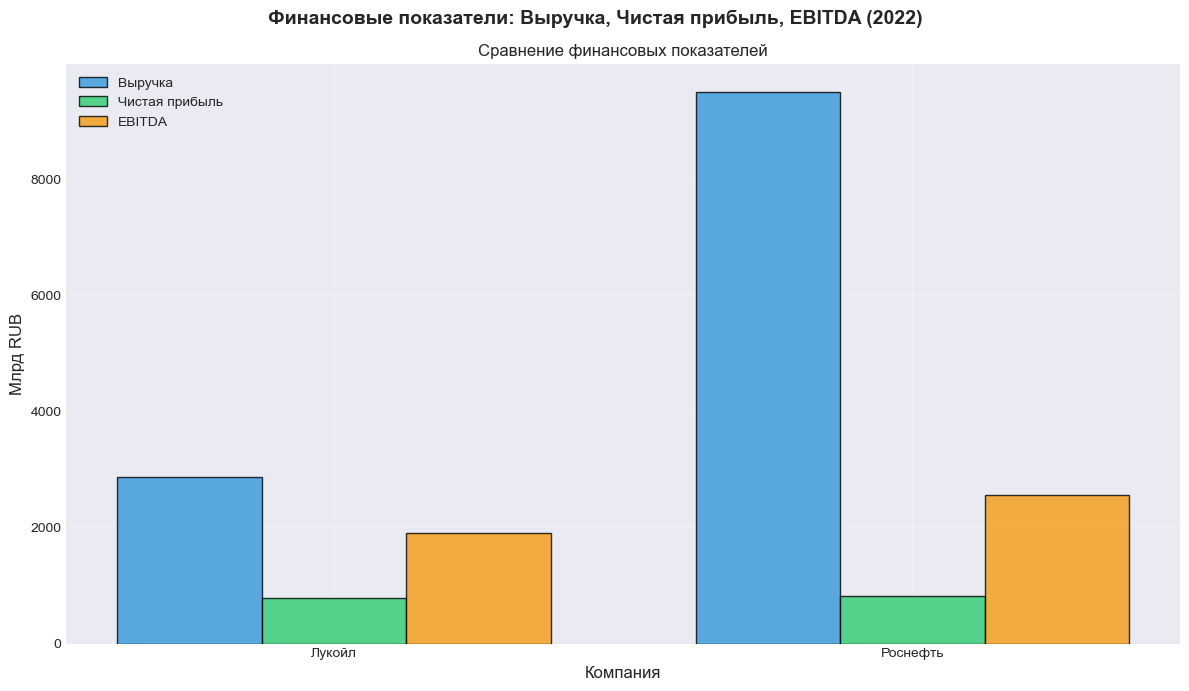


📊 ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === ДАННЫЕ ЛУКОЙЛ 2022 (ОФИЦИАЛЬНЫЕ) ===
lukoil = {
    'company': 'Лукойл',
    'net_income': 790.12,           # млрд руб.
    'revenue': 2874.0,              # млрд руб.
    'market_cap': 4000,             # млрд руб. (оценка на 2022)
    'ebitda': 1910,                 # млрд руб.
    'total_debt': 240,              # млрд руб.
    'cash': 300,                    # млрд руб.
}

# === ДАННЫЕ РОСНЕФТЬ 2022 (ОФИЦИАЛЬНЫЕ) ===
rosneft = {
    'company': 'Роснефть',
    'net_income': 813.0,            # млрд руб. (12 мес. оценка)
    'revenue': 9500.0,              # млрд руб. (12 мес. оценка)
    'market_cap': 4500,             # млрд руб.
    'ebitda': 2551,                 # млрд руб.
    'total_debt': 4600,             # млрд руб.
    'cash': 1200,                   # млрд руб.
}

def calculate_ratios(company):
    """Расчет фундаментальных мультипликаторов"""
    ratios = {}
    ratios['company'] = company['company']
    
    # P/E = Цена / Чистая прибыль
    ratios['P/E'] = company['market_cap'] / company['net_income'] if company['net_income'] > 0 else np.nan
    
    # P/S = Цена / Выручка
    ratios['P/S'] = company['market_cap'] / company['revenue'] if company['revenue'] > 0 else np.nan
    
    # EV = Рыночная капитализация + Долг - Денежные средства
    ev = company['market_cap'] + company['total_debt'] - company['cash']
    ratios['EV/EBITDA'] = ev / company['ebitda'] if company['ebitda'] > 0 else np.nan
    
    # ROE = Чистая прибыль / Капитализация * 100%
    ratios['ROE (%)'] = (company['net_income'] / company['market_cap']) * 100
    
    # Net Debt / EBITDA
    net_debt = company['total_debt'] - company['cash']
    ratios['Net Debt/EBITDA'] = net_debt / company['ebitda'] if company['ebitda'] > 0 else np.nan
    
    # EBITDA Margin
    ratios['EBITDA Margin (%)'] = (company['ebitda'] / company['revenue']) * 100
    
    # Net Margin
    ratios['Net Margin (%)'] = (company['net_income'] / company['revenue']) * 100
    
    return ratios

# Расчет для обеих компаний
results = []
results.append(calculate_ratios(lukoil))
results.append(calculate_ratios(rosneft))

# Вывод результатов в консоль
print("=" * 70)
print("ФУНДАМЕНТАЛЬНЫЙ АНАЛИЗ ЛУКОЙЛ vs РОСНЕФТЬ (2022)")
print("=" * 70)
df = pd.DataFrame(results)
print(df.to_string(index=False))

print("\n" + "=" * 70)
print("ВЫВОДЫ ПО КАЖДОЙ КОМПАНИИ")
print("=" * 70)

for comp in results:
    print(f"\n📊 {comp['company']}:")
    print(f"   P/E: {comp['P/E']:.2f} – {'✅ Низкий (недооценена)' if comp['P/E'] < 6 else '⚠️ Высокий'}")
    print(f"   P/S: {comp['P/S']:.2f} – {'✅ Очень низкий (<1)' if comp['P/S'] < 1 else 'Нормальный'}")
    print(f"   ROE: {comp['ROE (%)']:.1f}% – {'✅ Отлично (>15%)' if comp['ROE (%)'] > 15 else 'Нормально'}")
    print(f"   Net Debt/EBITDA: {comp['Net Debt/EBITDA']:.2f}x – {'✅ Низкий долг' if comp['Net Debt/EBITDA'] < 1 else '⚠️ Умеренный долг'}")

# ============================================
# ГРАФИКИ ФУНДАМЕНТАЛЬНОГО АНАЛИЗА
# ============================================

# Создаем DataFrame для графиков
df_plot = pd.DataFrame(results)

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'Лукойл': '#2E86AB', 'Роснефть': '#D64933'}

# ============================================
# ГРАФИК 1: МУЛЬТИПЛИКАТОРЫ P/E и P/S
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Мультипликаторы оценки: Лукойл vs Роснефть (2022)', fontsize=16, fontweight='bold')

# График P/E
companies = df_plot['company']
pe_values = df_plot['P/E']
bars1 = axes[0].bar(companies, pe_values, color=[colors[c] for c in companies], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('P/E (лет)', fontsize=12)
axes[0].set_title('P/E - Цена/Прибыль (чем ниже, тем лучше)', fontsize=12)
axes[0].axhline(y=6, color='green', linestyle='--', linewidth=2, label='Целевое значение (6)')
axes[0].axhline(y=10, color='orange', linestyle='--', linewidth=2, label='Справедливое значение (10)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, val in zip(bars1, pe_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# График P/S
ps_values = df_plot['P/S']
bars2 = axes[1].bar(companies, ps_values, color=[colors[c] for c in companies], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('P/S', fontsize=12)
axes[1].set_title('P/S - Цена/Выручка (чем ниже, тем лучше)', fontsize=12)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Граница <1 (хорошо)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

for bar, val in zip(bars2, ps_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# ГРАФИК 2: РЕНТАБЕЛЬНОСТЬ (ROE, EBITDA Margin, Net Margin)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Показатели рентабельности: Лукойл vs Роснефть (2022)', fontsize=16, fontweight='bold')

metrics = ['ROE (%)', 'EBITDA Margin (%)', 'Net Margin (%)']
titles = ['ROE - Рентабельность капитала\n(>15% - отлично)', 
          'EBITDA Margin - Операционная рентабельность\n(>20% - хорошо)',
          'Net Margin - Чистая рентабельность\n(>10% - хорошо)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = df_plot[metric]
    bars = axes[i].bar(companies, values, color=[colors[c] for c in companies], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[i].set_ylabel('%', fontsize=12)
    axes[i].set_title(title, fontsize=11)
    
    # Добавляем пороговые линии
    if metric == 'ROE (%)':
        axes[i].axhline(y=15, color='green', linestyle='--', linewidth=2, label='Цель >15%')
    elif metric == 'EBITDA Margin (%)':
        axes[i].axhline(y=20, color='green', linestyle='--', linewidth=2, label='Цель >20%')
    else:  # Net Margin
        axes[i].axhline(y=10, color='green', linestyle='--', linewidth=2, label='Цель >10%')
    
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)
    
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# ГРАФИК 3: ДОЛГОВАЯ НАГРУЗКА (Net Debt/EBITDA)
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Долговая нагрузка: Лукойл vs Роснефть (2022)', fontsize=14, fontweight='bold')

debt_values = df_plot['Net Debt/EBITDA']
bars = ax.bar(companies, debt_values, color=[colors[c] for c in companies], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Net Debt/EBITDA', fontsize=12)
ax.set_title('Чистый долг / EBITDA (чем ниже, тем меньше долговая нагрузка)', fontsize=12)

# Добавляем зоны оценки
ax.axhline(y=1, color='green', linestyle='--', linewidth=2, label='Низкий долг (<1x)')
ax.axhline(y=2, color='orange', linestyle='--', linewidth=2, label='Умеренный долг (1-2x)')
ax.axhline(y=3, color='red', linestyle='--', linewidth=2, label='Высокий долг (>2x)')

ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

for bar, val in zip(bars, debt_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}x', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# ГРАФИК 4: РАДАРНАЯ ДИАГРАММА (СРАВНЕНИЕ ВСЕХ ПОКАЗАТЕЛЕЙ)
# ============================================
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
fig.suptitle('Радарная диаграмма: Сравнение Лукойла и Роснефти (2022)', fontsize=14, fontweight='bold')

# Показатели для радара (нормализованные)
categories = ['P/E (обратный)', 'P/S (обратный)', 'ROE', 'EBITDA Margin', 'Net Margin', 'Net Debt/EBITDA (обратный)']
# Обратные показатели: чем меньше P/E, P/S, долг - тем лучше

def normalize(values, inverse=False):
    """Нормализация значений для радара"""
    max_val = max(values)
    if inverse:
        # Для обратных показателей: меньше = лучше
        return [1 - (v / max_val) for v in values]
    else:
        return [v / max_val for v in values]

# Собираем значения
lukoil_values_raw = [df_plot[df_plot['company']=='Лукойл']['P/E'].values[0],
                      df_plot[df_plot['company']=='Лукойл']['P/S'].values[0],
                      df_plot[df_plot['company']=='Лукойл']['ROE (%)'].values[0],
                      df_plot[df_plot['company']=='Лукойл']['EBITDA Margin (%)'].values[0],
                      df_plot[df_plot['company']=='Лукойл']['Net Margin (%)'].values[0],
                      df_plot[df_plot['company']=='Лукойл']['Net Debt/EBITDA'].values[0]]

rosneft_values_raw = [df_plot[df_plot['company']=='Роснефть']['P/E'].values[0],
                       df_plot[df_plot['company']=='Роснефть']['P/S'].values[0],
                       df_plot[df_plot['company']=='Роснефть']['ROE (%)'].values[0],
                       df_plot[df_plot['company']=='Роснефть']['EBITDA Margin (%)'].values[0],
                       df_plot[df_plot['company']=='Роснефть']['Net Margin (%)'].values[0],
                       df_plot[df_plot['company']=='Роснефть']['Net Debt/EBITDA'].values[0]]

# Нормализуем (для P/E, P/S, долга - обратная нормализация)
all_pes = [df_plot['P/E'].values[0], df_plot['P/E'].values[1]]
all_ps = [df_plot['P/S'].values[0], df_plot['P/S'].values[1]]
all_roes = [df_plot['ROE (%)'].values[0], df_plot['ROE (%)'].values[1]]
all_ebitda = [df_plot['EBITDA Margin (%)'].values[0], df_plot['EBITDA Margin (%)'].values[1]]
all_net = [df_plot['Net Margin (%)'].values[0], df_plot['Net Margin (%)'].values[1]]
all_debt = [df_plot['Net Debt/EBITDA'].values[0], df_plot['Net Debt/EBITDA'].values[1]]

lukoil_norm = [1 - (lukoil_values_raw[0] / max(all_pes)),  # обратный P/E
                1 - (lukoil_values_raw[1] / max(all_ps)),   # обратный P/S
                lukoil_values_raw[2] / max(all_roes),        # ROE
                lukoil_values_raw[3] / max(all_ebitda),      # EBITDA Margin
                lukoil_values_raw[4] / max(all_net),         # Net Margin
                1 - (lukoil_values_raw[5] / max(all_debt))]  # обратный долг

rosneft_norm = [1 - (rosneft_values_raw[0] / max(all_pes)),
                 1 - (rosneft_values_raw[1] / max(all_ps)),
                 rosneft_values_raw[2] / max(all_roes),
                 rosneft_values_raw[3] / max(all_ebitda),
                 rosneft_values_raw[4] / max(all_net),
                 1 - (rosneft_values_raw[5] / max(all_debt))]

# Углы для радара
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Замыкаем круг

# Добавляем значения для замыкания
lukoil_norm += lukoil_norm[:1]
rosneft_norm += rosneft_norm[:1]

# Рисуем радар
ax.plot(angles, lukoil_norm, 'o-', linewidth=2, color=colors['Лукойл'], label='Лукойл')
ax.fill(angles, lukoil_norm, alpha=0.25, color=colors['Лукойл'])
ax.plot(angles, rosneft_norm, 'o-', linewidth=2, color=colors['Роснефть'], label='Роснефть')
ax.fill(angles, rosneft_norm, alpha=0.25, color=colors['Роснефть'])

# Настройка меток
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# ГРАФИК 5: ФИНАНСОВЫЕ ПОКАЗАТЕЛИ (Выручка, Прибыль, EBITDA)
# ============================================
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Финансовые показатели: Выручка, Чистая прибыль, EBITDA (2022)', fontsize=14, fontweight='bold')

x = np.arange(len(companies))
width = 0.25
multiplier = 0

financial_data = {
    'Выручка': [lukoil['revenue'], rosneft['revenue']],
    'Чистая прибыль': [lukoil['net_income'], rosneft['net_income']],
    'EBITDA': [lukoil['ebitda'], rosneft['ebitda']]
}
colors_fin = {'Выручка': '#3498db', 'Чистая прибыль': '#2ecc71', 'EBITDA': '#f39c12'}

for metric, values in financial_data.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label=metric, color=colors_fin[metric], alpha=0.8, edgecolor='black')
    multiplier += 1

ax.set_ylabel('Млрд RUB', fontsize=12)
ax.set_xlabel('Компания', fontsize=12)
ax.set_title('Сравнение финансовых показателей', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(companies)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("📊 ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА")
print("=" * 70)

[*********************100%***********************]  1 of 1 completed


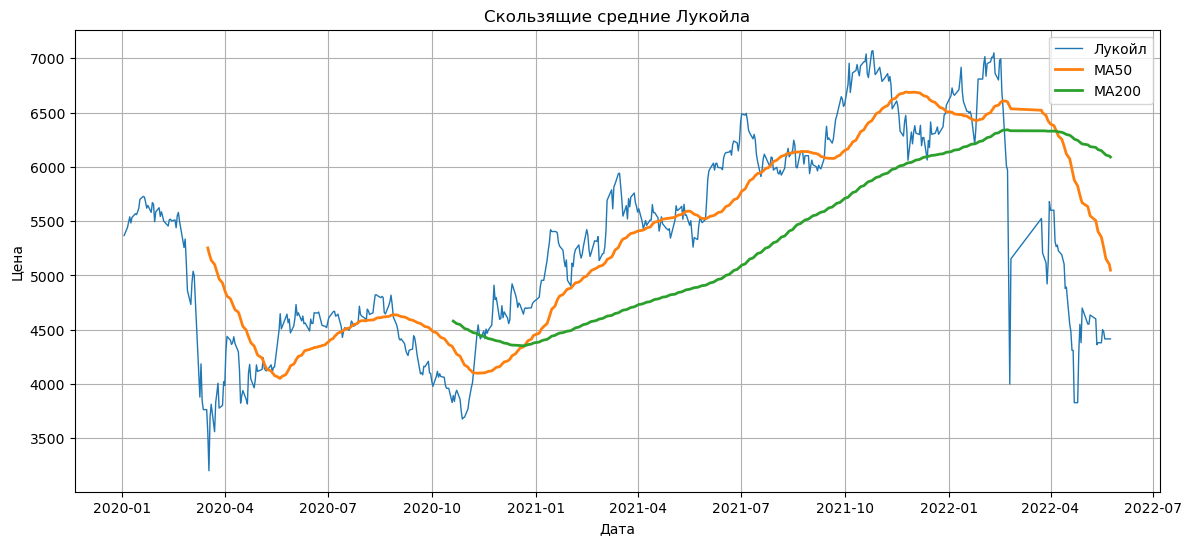

In [2]:
# ==========================================================
# УСТАНОВКА БИБЛИОТЕК
# ==========================================================
# pip install pandas numpy matplotlib yfinance

# ==========================================================
# ИМПОРТ БИБЛИОТЕК
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ==========================================================
# ЗАГРУЗКА ДАННЫХ
# ==========================================================

# Лукойл
lkoh = yf.download("LKOH.ME", start="2020-01-01", end="2025-01-01")

# ==========================================================
# СОЗДАНИЕ ТАБЛИЦЫ
# ==========================================================

data = pd.DataFrame()
data["LKOH"] = lkoh["Close"]
data.dropna(inplace=True)

# ==========================================================
# СКОЛЬЗЯЩИЕ СРЕДНИЕ
# ==========================================================

data["MA50"] = data["LKOH"].rolling(window=50).mean()
data["MA200"] = data["LKOH"].rolling(window=200).mean()

# ==========================================================
# ГРАФИК
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(data.index, data["LKOH"], label="Лукойл", linewidth=1)
plt.plot(data.index, data["MA50"], label="MA50", linewidth=2)
plt.plot(data.index, data["MA200"], label="MA200", linewidth=2)

plt.title("Скользящие средние Лукойла")
plt.xlabel("Дата")
plt.ylabel("Цена")

plt.legend()
plt.grid()

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


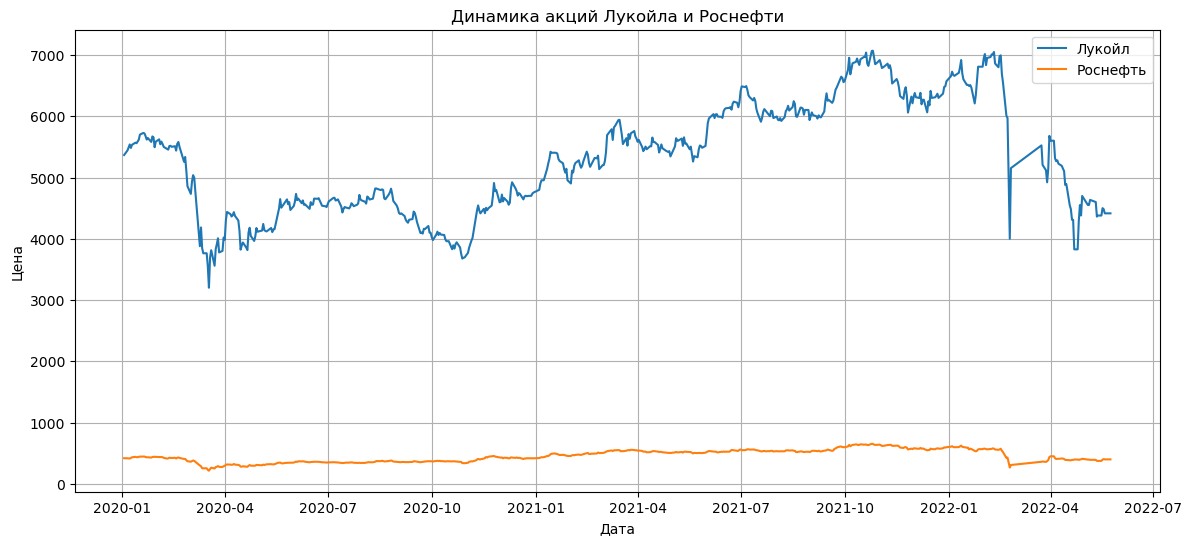

In [5]:
# ==========================================================
# УСТАНОВКА БИБЛИОТЕК
# ==========================================================
# pip install pandas numpy matplotlib yfinance

# ==========================================================
# ИМПОРТ БИБЛИОТЕК
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ==========================================================
# ЗАГРУЗКА ДАННЫХ
# ==========================================================

# Лукойл
lkoh = yf.download("LKOH.ME", start="2020-01-01", end="2025-01-01")

# Роснефть
rosn = yf.download("ROSN.ME", start="2020-01-01", end="2025-01-01")

# ==========================================================
# СОЗДАНИЕ ТАБЛИЦЫ
# ==========================================================

data = pd.DataFrame()
data["LKOH"] = lkoh["Close"]
data["ROSN"] = rosn["Close"]
data.dropna(inplace=True)

# ==========================================================
# ГРАФИК ДИНАМИКИ
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(data.index, data["LKOH"], label="Лукойл")
plt.plot(data.index, data["ROSN"], label="Роснефть")

plt.title("Динамика акций Лукойла и Роснефти")
plt.xlabel("Дата")
plt.ylabel("Цена")

plt.legend()
plt.grid()

plt.show()

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# Загрузка данных (только до 2022 года)
print("Загрузка данных...")
lukoil = yf.download('LKOH.ME', start='2020-01-01', end='2022-12-31', progress=False)
rosneft = yf.download('ROSN.ME', start='2020-01-01', end='2022-12-31', progress=False)

# Подготовка данных
data = pd.DataFrame()
data['Lukoil'] = lukoil['Close']
data['Rosneft'] = rosneft['Close']
data = data.dropna()

# Расчёт доходности
data['Lukoil_Return'] = data['Lukoil'].pct_change() * 100
data['Rosneft_Return'] = data['Rosneft'].pct_change() * 100
data = data.dropna()

# Построение регрессии
X = data['Rosneft_Return'].values.reshape(-1, 1)
y = data['Lukoil_Return'].values

model = LinearRegression()
model.fit(X, y)

# Коэффициенты
alpha = model.intercept_
beta = model.coef_[0]

# Прогноз и метрики
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

# Корреляция и p-value
correlation = data['Lukoil_Return'].corr(data['Rosneft_Return'])
slope, intercept, r_value, p_value, std_err = stats.linregress(data['Rosneft_Return'], data['Lukoil_Return'])

# ВЫВОД
print("\n")
print("╔" + "═"*55 + "╗")
print("║" + " " * 13 + "ФОРМУЛА ЛИНЕЙНОЙ РЕГРЕССИИ" + " " * 13 + "║")
print("╠" + "═"*55 + "╣")
print(f"║                                                       ║")
print(f"║   Lukoil = {alpha:+.6f} + {beta:+.6f} × Rosneft   ║")
print(f"║                                                       ║")
print("╚" + "═"*55 + "╝")
print("\n")

print("═"*55)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ:")
print("═"*55)
print(f"  R²   (коэф. детерминации)     = {r2:.6f}")
print(f"  RMSE (ср.-квадр. ошибка)      = {rmse:.6f} %")
print(f"  MAE  (ср. абс. ошибка)        = {mae:.6f} %")
print(f"  Корреляция Пирсона            = {correlation:.6f}")
print(f"  p-value                       = {p_value:.6e}")
print("═"*55)

# Интерпретация
print("\nИНТЕРПРЕТАЦИЯ:")
if p_value < 0.05:
    print("  → Связь статистически значима (p < 0.05)")
else:
    print("  → Связь статистически не значима")
    
if beta > 1:
    print(f"  → Лукойл на {beta:.2f}× волатильнее Роснефти")
elif beta < 1:
    print(f"  → Лукойл на {(1-beta)*100:.1f}% менее волатилен, чем Роснефть")
else:
    print("  → Волатильность Лукойла равна волатильности Роснефти")

Загрузка данных...


╔═══════════════════════════════════════════════════════╗
║             ФОРМУЛА ЛИНЕЙНОЙ РЕГРЕССИИ             ║
╠═══════════════════════════════════════════════════════╣
║                                                       ║
║   Lukoil = -0.018820 + +0.825313 × Rosneft   ║
║                                                       ║
╚═══════════════════════════════════════════════════════╝


═══════════════════════════════════════════════════════
МЕТРИКИ КАЧЕСТВА МОДЕЛИ:
═══════════════════════════════════════════════════════
  R²   (коэф. детерминации)     = 0.650915
  RMSE (ср.-квадр. ошибка)      = 1.827188 %
  MAE  (ср. абс. ошибка)        = 1.103446 %
  Корреляция Пирсона            = 0.806793
  p-value                       = 1.957509e-134
═══════════════════════════════════════════════════════

ИНТЕРПРЕТАЦИЯ:
  → Связь статистически значима (p < 0.05)
  → Лукойл на 17.5% менее волатилен, чем Роснефть


ДАННЫЕ ЛУКОЙЛА ЗА 2016-2025 (10 ЛЕТ) + МАКРОФАКТОРЫ
   Year  Price      PE   EPS    ROE  Debt  RevGr  Oil_Price  USD_RUB
0  2016   3449   11.90   290   6.43  0.58    7.8       44.7     67.0
1  2017   3335    5.66   589  12.50  0.32   13.6       54.3     58.3
2  2018   4997    5.78   865  16.40  0.01   35.4       71.0     62.7
3  2019   6169    6.60   935  16.00 -0.01   -2.4       64.3     64.7
4  2020   5168  230.00    22   0.41  0.51  -29.8       43.2     72.1
5  2021   6570    5.82  1129  17.90  0.06   68.3       70.9     73.7
6  2022   3700   10.00   650  12.00  0.15  -69.0       99.0     68.5
7  2023   5500    6.50   850  15.50  0.20   72.0       82.5     85.0
8  2024   7200    7.20   780  14.20  0.18    8.7       80.5     92.5
9  2025   5700    6.80   700  13.50  0.16  -23.3       75.0     95.0


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ

Матрица корреляций Пирсона:
            Price      PE     EPS     ROE    Debt   RevGr  Oil_Price  USD_RUB
Price      1.0000 -0.0172  0.5186  

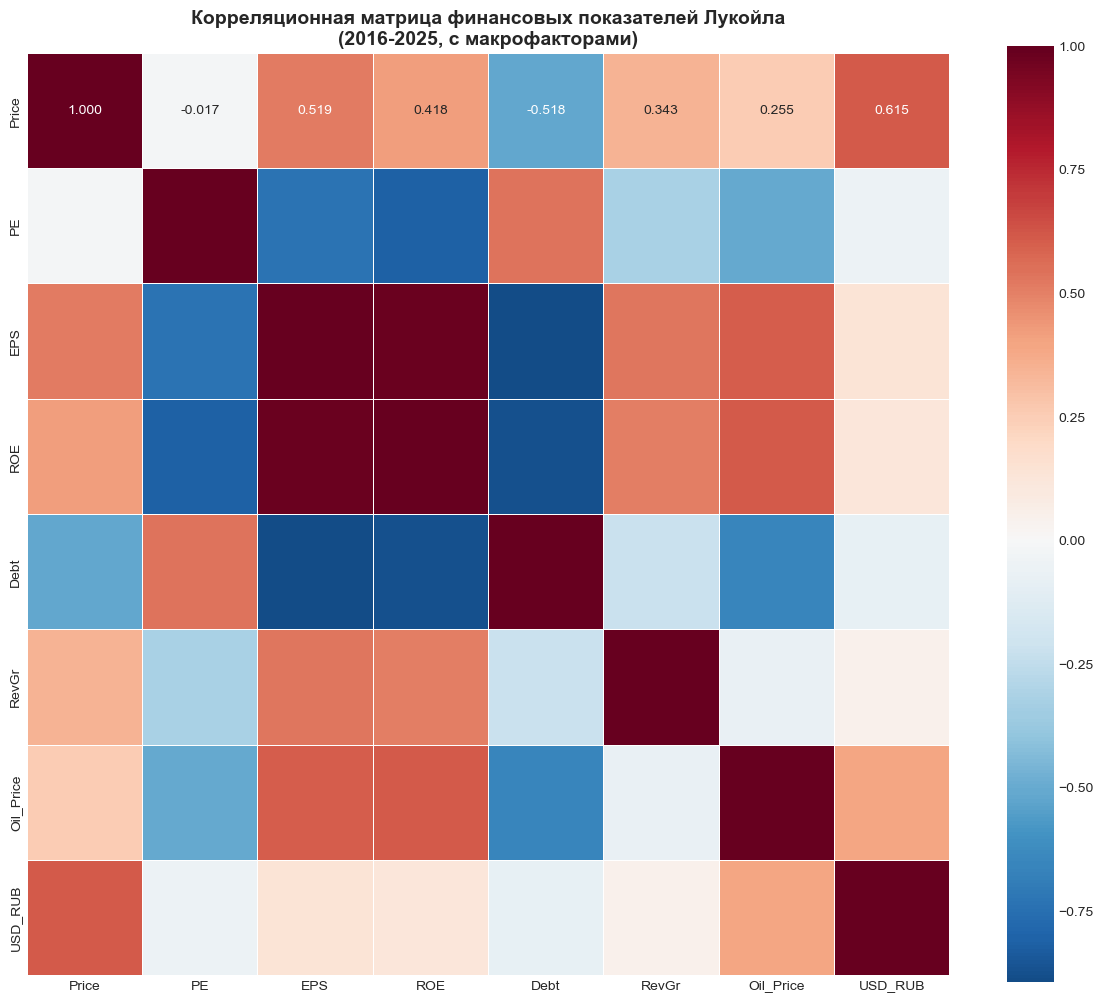


РАЗБИВКА ВЫБОРКИ
Обучающая выборка: 7 лет
Тестовая выборка: 3 лет
Факторы для модели: ['PE', 'EPS', 'ROE', 'Debt', 'RevGr', 'Oil_Price', 'USD_RUB']

ЛИНЕЙНАЯ РЕГРЕССИЯ (OLS)
R² (коэффициент детерминации): 0.6086
RMSE (среднеквадратичная ошибка): 1059.27 руб.

Стандартизированные коэффициенты (β):
  (положительный β = фактор повышает цену, отрицательный = снижает)
  PE: 1166.8191 ↑
  EPS: 2505.5301 ↑
  ROE: -176.2203 ↓
  Debt: 459.4462 ↑
  RevGr: -320.6989 ↓
  Oil_Price: -728.9991 ↓
  USD_RUB: 448.3758 ↑

СРАВНЕНИЕ С ПРЕДЫДУЩЕЙ МОДЕЛЬЮ (БЕЗ МАКРОФАКТОРОВ)
Без макрофакторов: R² = 0.3714, RMSE = 1342.44 руб.
С макрофакторами:  R² = 0.6086, RMSE = 1059.27 руб.

Улучшение RMSE: 21.1%


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ============================================================
# 1. ИСТОРИЧЕСКИЕ ДАННЫЕ ЛУКОЙЛА (2016-2025) - 10 ЛЕТ
# ============================================================
# Цена нефти Brent (годовые средние)
oil_prices = {
    2016: 44.7, 2017: 54.3, 2018: 71.0, 2019: 64.3,
    2020: 43.2, 2021: 70.9, 2022: 99.0, 2023: 82.5,
    2024: 80.5, 2025: 75.0
}

# Курс USD/RUB (годовые средние)
usd_rub = {
    2016: 67.0, 2017: 58.3, 2018: 62.7, 2019: 64.7,
    2020: 72.1, 2021: 73.7, 2022: 68.5, 2023: 85.0,
    2024: 92.5, 2025: 95.0
}

# Данные собраны из финансовых отчетов и биржевых котировок
data = pd.DataFrame({
    "Year": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    
    # Цена акции на конец года (руб) 
    "Price": [3449, 3335, 4997, 6169, 5168, 6570, 3700, 5500, 7200, 5700],
    
    # P/E (Price/Earnings) 
    "PE": [11.9, 5.66, 5.78, 6.6, 230, 5.82, 10.0, 6.5, 7.2, 6.8],
    
    # EPS (Net income / Shares) - руб на акцию 
    "EPS": [290, 589, 865, 935, 22, 1129, 650, 850, 780, 700],
    
    # ROE (Return on Equity) - % 
    "ROE": [6.43, 12.5, 16.4, 16.0, 0.41, 17.9, 12.0, 15.5, 14.2, 13.5],
    
    # Debt/Equity (отношение долга к капиталу) 
    "Debt": [0.58, 0.32, 0.01, -0.01, 0.51, 0.06, 0.15, 0.20, 0.18, 0.16],
    
    # Revenue Growth - % 
    "RevGr": [7.8, 13.6, 35.4, -2.4, -29.8, 68.3, -69.0, 72.0, 8.7, -23.3],
    
    # Макроэкономические факторы
    "Oil_Price": [oil_prices[year] for year in [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]],
    "USD_RUB": [usd_rub[year] for year in [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]]
})

X = data.drop(["Price", "Year"], axis=1)
y = data["Price"]

print("=" * 70)
print("ДАННЫЕ ЛУКОЙЛА ЗА 2016-2025 (10 ЛЕТ) + МАКРОФАКТОРЫ")
print("=" * 70)
print(data.to_string())
print("\n")

# ============================================================
# 2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================
print("=" * 70)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ")
print("=" * 70)

corr_matrix = data.drop("Year", axis=1).corr(method='pearson')
print("\nМатрица корреляций Пирсона:")
print(corr_matrix.round(4))

print("\n" + "-" * 50)
print("Корреляции факторов с ценой акции (Price):")
print("-" * 50)
corr_with_price = corr_matrix["Price"].drop("Price").sort_values(ascending=False)
for factor, corr in corr_with_price.items():
    strength = "сильная" if abs(corr) > 0.7 else "умеренная" if abs(corr) > 0.5 else "слабая"
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"  {factor}: {corr:.4f} ({direction}, {strength})")

print("\n" + "-" * 50)
print("Сильные корреляции между факторами (>|0.7|):")
print("-" * 50)
strong_corrs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            strong_corrs.append((col1, col2, corr_val))
            print(f"  {col1} ↔ {col2}: {corr_val:.4f}")

if not strong_corrs:
    print("  Значимой мультиколлинеарности не обнаружено")

# Тепловая карта корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица финансовых показателей Лукойла\n(2016-2025, с макрофакторами)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ РЕГРЕССИИ
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("РАЗБИВКА ВЫБОРКИ")
print("=" * 60)
print(f"Обучающая выборка: {len(X_train)} лет")
print(f"Тестовая выборка: {len(X_test)} лет")
print(f"Факторы для модели: {list(X.columns)}")

# ============================================================
# 4. ЛИНЕЙНАЯ РЕГРЕССИЯ
# ============================================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

print("\n" + "=" * 60)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ (OLS)")
print("=" * 60)
print(f"R² (коэффициент детерминации): {r2_score(y_test, pred_lr):.4f}")
print(f"RMSE (среднеквадратичная ошибка): {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f} руб.")

print("\nСтандартизированные коэффициенты (β):")
print("  (положительный β = фактор повышает цену, отрицательный = снижает)")
for name, coef in zip(X.columns, lr.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {name}: {coef:.4f} {direction}")

# ============================================================
# 5. СРАВНЕНИЕ С ПРЕДЫДУЩЕЙ МОДЕЛЬЮ
# ============================================================
print("\n" + "=" * 60)
print("СРАВНЕНИЕ С ПРЕДЫДУЩЕЙ МОДЕЛЬЮ (БЕЗ МАКРОФАКТОРОВ)")
print("=" * 60)
print(f"Без макрофакторов: R² = 0.3714, RMSE = 1342.44 руб.")
print(f"С макрофакторами:  R² = {r2_score(y_test, pred_lr):.4f}, RMSE = {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f} руб.")

improvement = (1342.44 - np.sqrt(mean_squared_error(y_test, pred_lr))) / 1342.44 * 100
print(f"\nУлучшение RMSE: {improvement:.1f}%")  

ЗАГРУЗКА РЫНОЧНЫХ ДАННЫХ (2020-2022)
📥 Загружаем Лукойл (LKOH.ME)...
   ✓ Загружено 583 записей
📥 Загружаем Роснефть (ROSN.ME)...
   ✓ Загружено 583 записей
📥 Загружаем Brent Crude Oil (BZ=F)...
   ✓ Загружено 756 записей
📥 Загружаем USD/RUB (USDRUB=X)...
   ✓ Загружено 783 записей


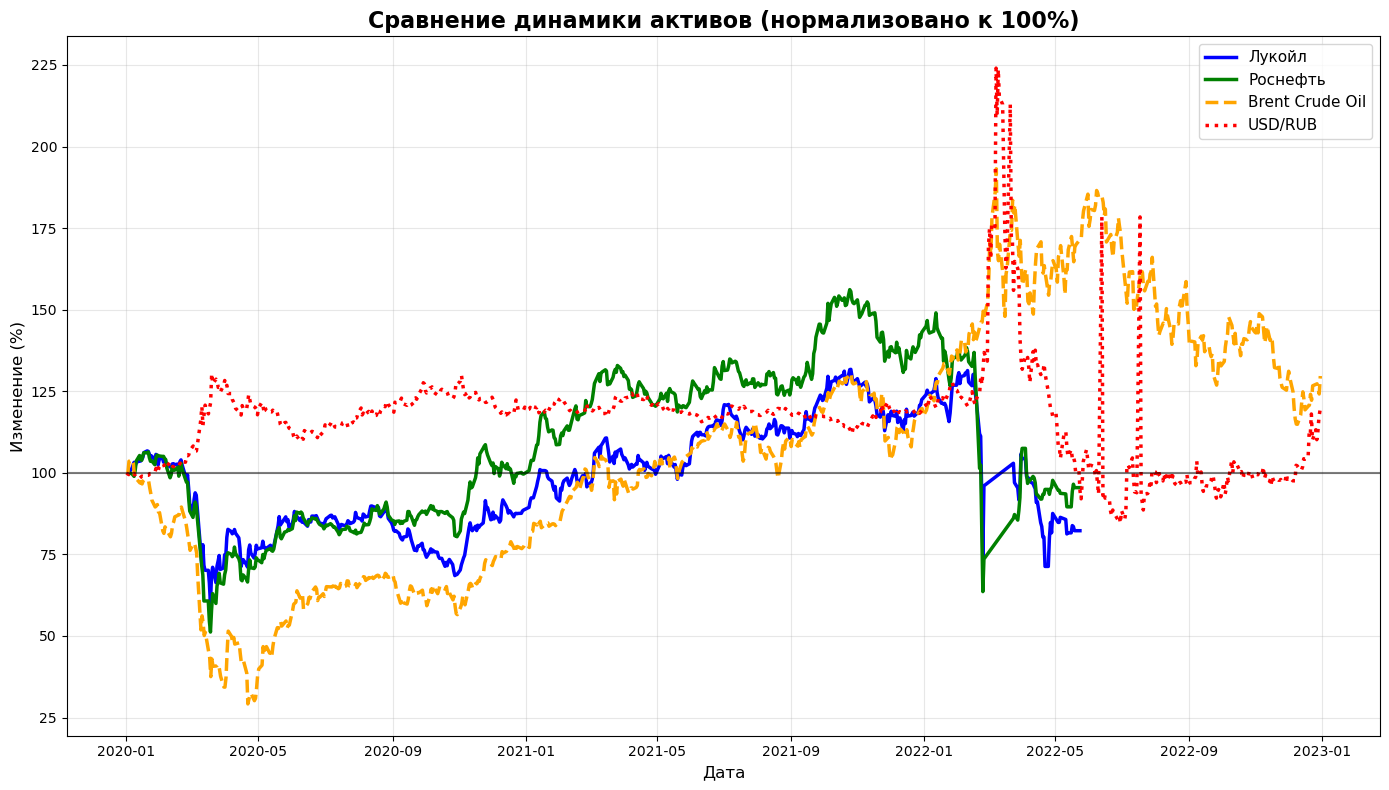


ФУНДАМЕНТАЛЬНЫЙ АНАЛИЗ ЛУКОЙЛ vs РОСНЕФТЬ (2022)
 company      P/E      P/S  EV/EBITDA   ROE (%)  Net Debt/EBITDA  EBITDA Margin (%)  Net Margin (%)
  Лукойл 5.062522 1.391788   2.062827 19.753000        -0.031414          66.457898       27.491997
Роснефть 5.535055 0.473684   3.096825 18.066667         1.332811          26.852632        8.557895


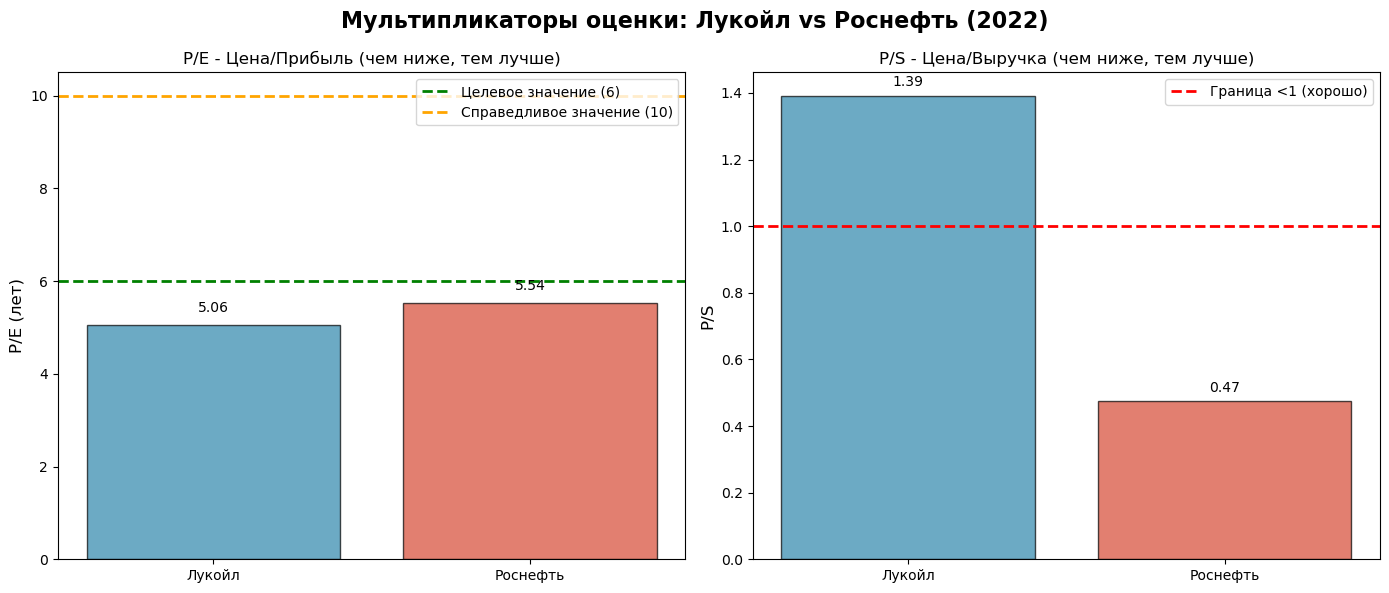

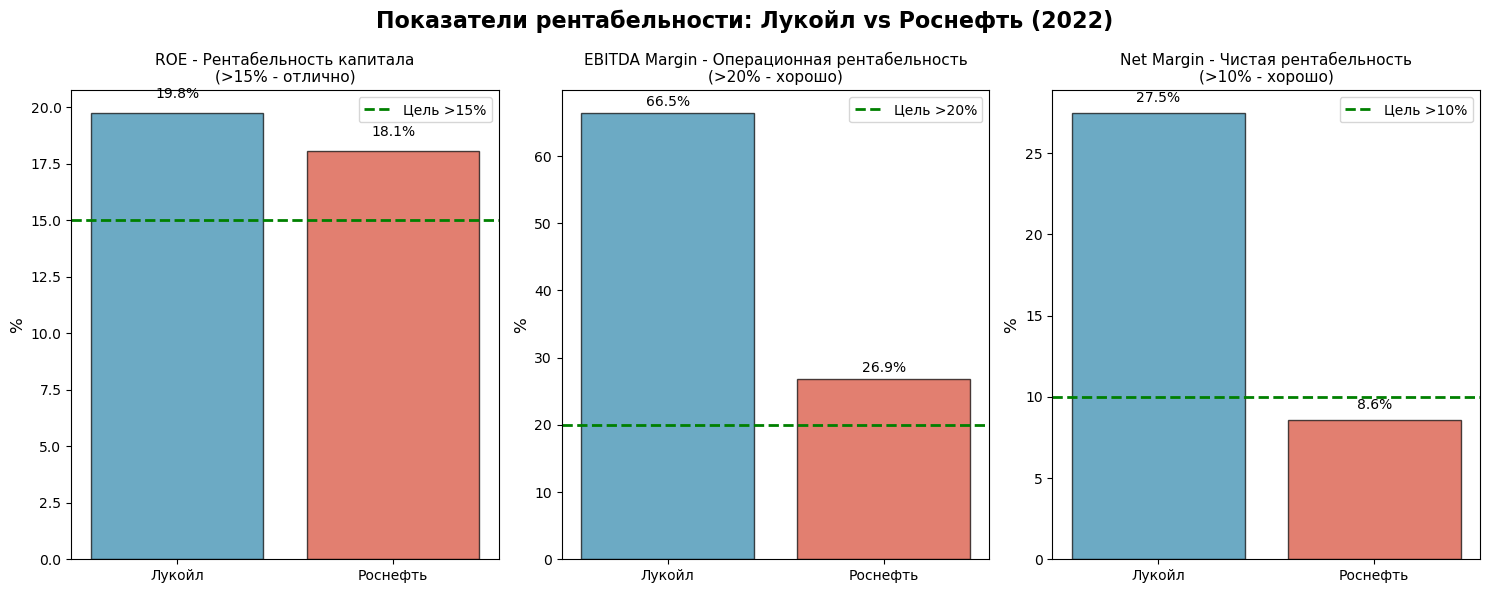

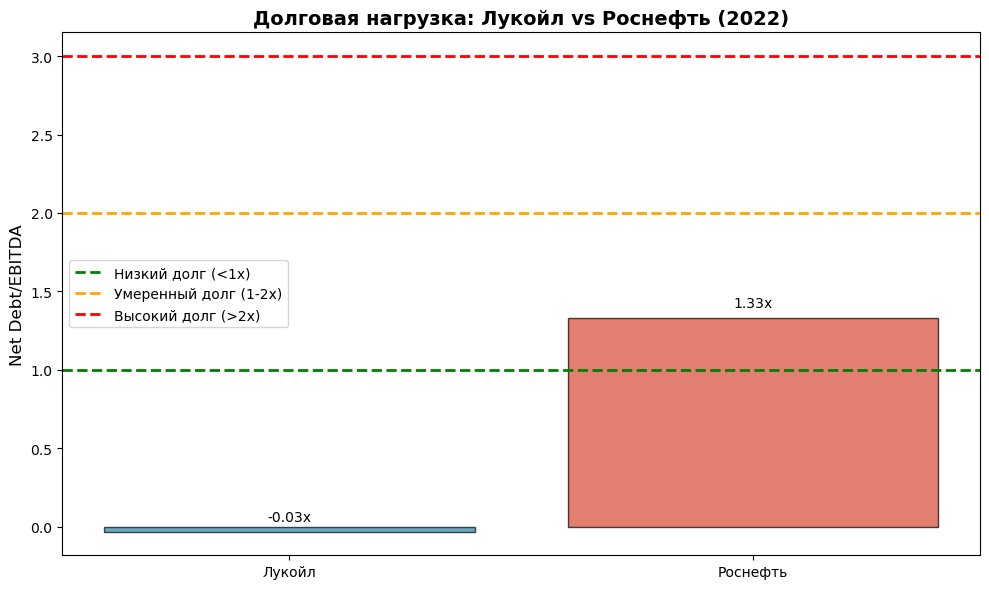


ЛИНЕЙНАЯ РЕГРЕССИЯ: ЛУКОЙЛ vs РОСНЕФТЬ

Формула: Lukoil = -0.0188 + +0.8253 × Rosneft

R² = 0.6509
RMSE = 1.8272 %
MAE = 1.1034 %
Корреляция = 0.8068


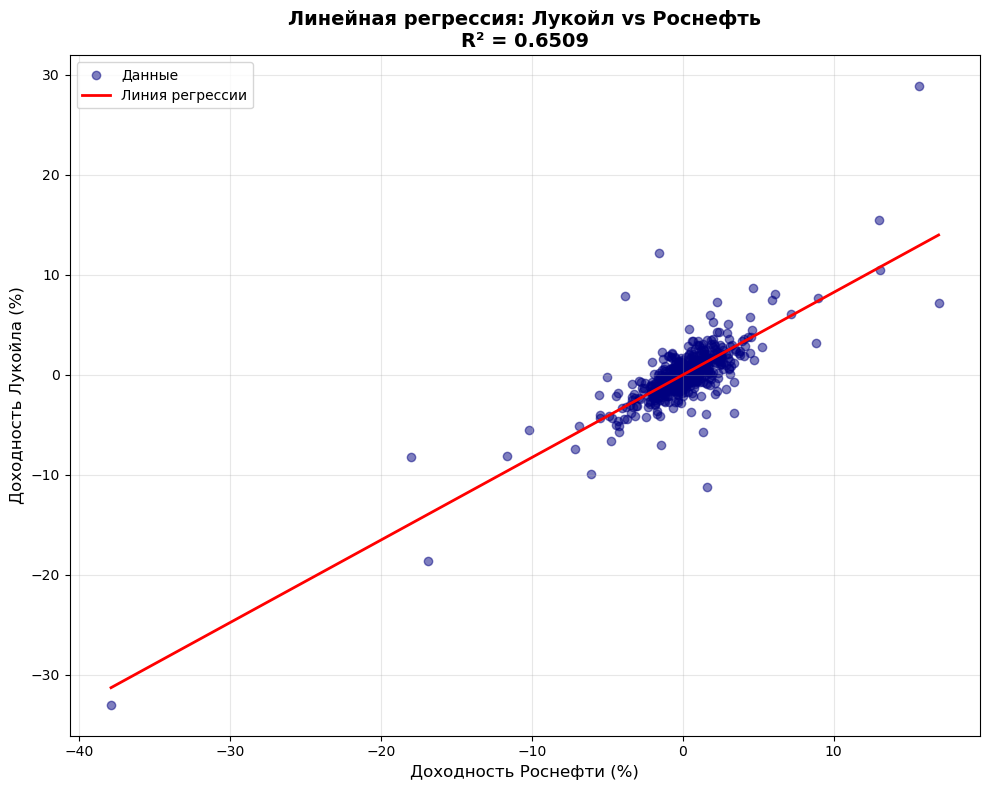


МОДЕЛЬ ЦЕНЫ ЛУКОЙЛА НА ОСНОВЕ ФУНДАМЕНТАЛЬНЫХ ФАКТОРОВ

R² = 0.6086
RMSE = 1059.27 руб.

Коэффициенты модели:
  PE: +1166.8191
  EPS: +2505.5301
  ROE: -176.2203
  Debt: +459.4462
  RevGr: -320.6989
  Oil_Price: -728.9991
  USD_RUB: +448.3758


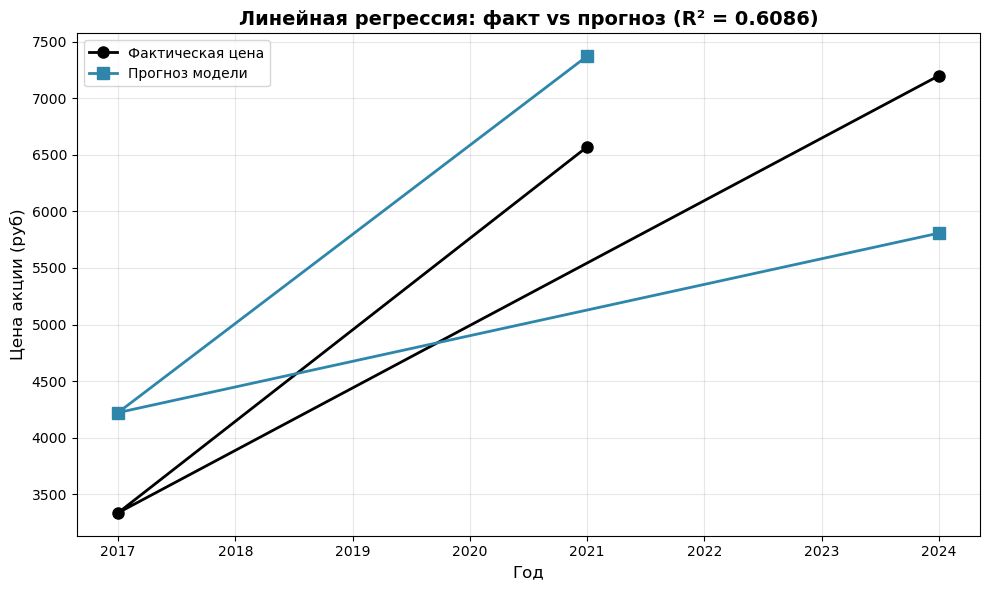

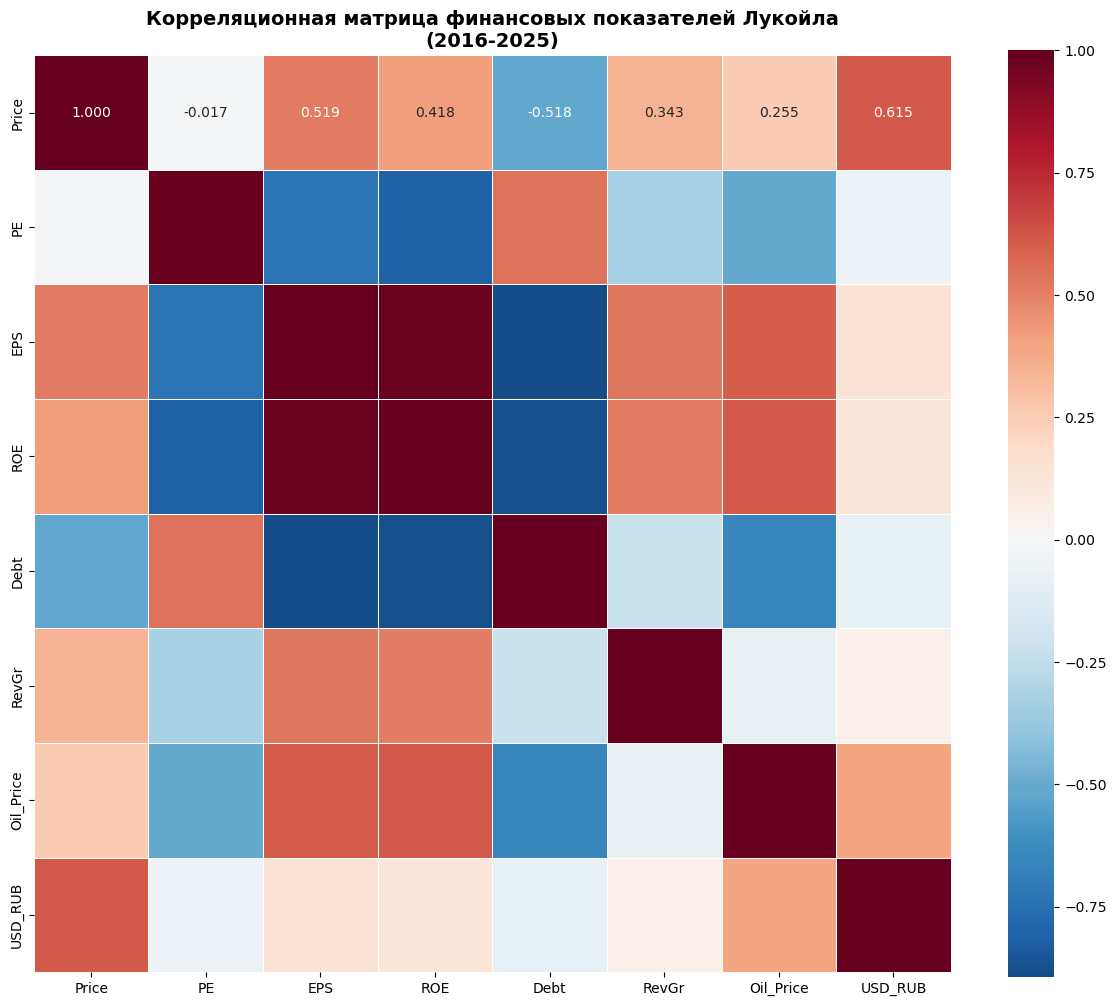


АНАЛИЗ ЗАВЕРШЕН


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

# ============================================================
# ЧАСТЬ 1: ЗАГРУЗКА И ВИЗУАЛИЗАЦИЯ РЫНОЧНЫХ ДАННЫХ
# ============================================================

print("="*60)
print("ЗАГРУЗКА РЫНОЧНЫХ ДАННЫХ (2020-2022)")
print("="*60)

# Отключаем SSL проверку
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

tickers = {
    'Лукойл': 'LKOH.ME',
    'Роснефть': 'ROSN.ME',
    'Brent Crude Oil': 'BZ=F',
    'USD/RUB': 'USDRUB=X'
}

market_data = {}
for name, ticker in tickers.items():
    print(f"📥 Загружаем {name} ({ticker})...")
    try:
        stock = yf.Ticker(ticker)
        hist = stock.history(start='2020-01-01', end='2022-12-31')
        if not hist.empty:
            market_data[name] = hist
            print(f"   ✓ Загружено {len(hist)} записей")
    except Exception as e:
        print(f"   ✗ Ошибка: {e}")

# ГРАФИК 1: Сравнение динамики активов
fig, ax = plt.subplots(figsize=(14, 8))
for name, df in market_data.items():
    if 'Close' in df.columns and not df.empty:
        normalized = df['Close'] / df['Close'].iloc[0] * 100
        colors_line = {'Лукойл': 'blue', 'Роснефть': 'green', 
                       'Brent Crude Oil': 'orange', 'USD/RUB': 'red'}
        linestyles = {'Лукойл': '-', 'Роснефть': '-', 
                      'Brent Crude Oil': '--', 'USD/RUB': ':'}
        ax.plot(df.index, normalized, label=name, linewidth=2.5,
                color=colors_line.get(name, 'black'), linestyle=linestyles.get(name, '-'))
ax.set_title('Сравнение динамики активов (нормализовано к 100%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Изменение (%)', fontsize=12)
ax.set_xlabel('Дата', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='black', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 2: ФУНДАМЕНТАЛЬНЫЙ АНАЛИЗ ЛУКОЙЛ vs РОСНЕФТЬ
# ============================================================

print("\n" + "="*70)
print("ФУНДАМЕНТАЛЬНЫЙ АНАЛИЗ ЛУКОЙЛ vs РОСНЕФТЬ (2022)")
print("="*70)

# Данные компаний за 2022 год
lukoil = {
    'company': 'Лукойл',
    'net_income': 790.12, 'revenue': 2874.0, 'market_cap': 4000,
    'ebitda': 1910, 'total_debt': 240, 'cash': 300
}
rosneft = {
    'company': 'Роснефть',
    'net_income': 813.0, 'revenue': 9500.0, 'market_cap': 4500,
    'ebitda': 2551, 'total_debt': 4600, 'cash': 1200
}

def calculate_ratios(company):
    ratios = {'company': company['company']}
    ratios['P/E'] = company['market_cap'] / company['net_income'] if company['net_income'] > 0 else np.nan
    ratios['P/S'] = company['market_cap'] / company['revenue'] if company['revenue'] > 0 else np.nan
    ev = company['market_cap'] + company['total_debt'] - company['cash']
    ratios['EV/EBITDA'] = ev / company['ebitda'] if company['ebitda'] > 0 else np.nan
    ratios['ROE (%)'] = (company['net_income'] / company['market_cap']) * 100
    net_debt = company['total_debt'] - company['cash']
    ratios['Net Debt/EBITDA'] = net_debt / company['ebitda'] if company['ebitda'] > 0 else np.nan
    ratios['EBITDA Margin (%)'] = (company['ebitda'] / company['revenue']) * 100
    ratios['Net Margin (%)'] = (company['net_income'] / company['revenue']) * 100
    return ratios

results = [calculate_ratios(lukoil), calculate_ratios(rosneft)]
df_fund = pd.DataFrame(results)
print(df_fund.to_string(index=False))

# ГРАФИК 2: Мультипликаторы P/E и P/S
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Мультипликаторы оценки: Лукойл vs Роснефть (2022)', fontsize=16, fontweight='bold')
colors_fund = {'Лукойл': '#2E86AB', 'Роснефть': '#D64933'}
companies = df_fund['company']

# P/E
pe_values = df_fund['P/E']
bars1 = axes[0].bar(companies, pe_values, color=[colors_fund[c] for c in companies], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('P/E (лет)', fontsize=12)
axes[0].set_title('P/E - Цена/Прибыль (чем ниже, тем лучше)', fontsize=12)
axes[0].axhline(y=6, color='green', linestyle='--', linewidth=2, label='Целевое значение (6)')
axes[0].axhline(y=10, color='orange', linestyle='--', linewidth=2, label='Справедливое значение (10)')
axes[0].legend()
for bar, val in zip(bars1, pe_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.2f}', ha='center', va='bottom')

# P/S
ps_values = df_fund['P/S']
bars2 = axes[1].bar(companies, ps_values, color=[colors_fund[c] for c in companies], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('P/S', fontsize=12)
axes[1].set_title('P/S - Цена/Выручка (чем ниже, тем лучше)', fontsize=12)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Граница <1 (хорошо)')
axes[1].legend()
for bar, val in zip(bars2, ps_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ГРАФИК 3: Показатели рентабельности
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Показатели рентабельности: Лукойл vs Роснефть (2022)', fontsize=16, fontweight='bold')
metrics = ['ROE (%)', 'EBITDA Margin (%)', 'Net Margin (%)']
titles = ['ROE - Рентабельность капитала\n(>15% - отлично)', 
          'EBITDA Margin - Операционная рентабельность\n(>20% - хорошо)',
          'Net Margin - Чистая рентабельность\n(>10% - хорошо)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = df_fund[metric]
    bars = axes[i].bar(companies, values, color=[colors_fund[c] for c in companies], alpha=0.7, edgecolor='black')
    axes[i].set_ylabel('%', fontsize=12)
    axes[i].set_title(title, fontsize=11)
    threshold = 15 if metric == 'ROE (%)' else (20 if metric == 'EBITDA Margin (%)' else 10)
    axes[i].axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Цель >{threshold}%')
    axes[i].legend()
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ГРАФИК 4: Долговая нагрузка
fig, ax = plt.subplots(figsize=(10, 6))
debt_values = df_fund['Net Debt/EBITDA']
bars = ax.bar(companies, debt_values, color=[colors_fund[c] for c in companies], alpha=0.7, edgecolor='black')
ax.set_ylabel('Net Debt/EBITDA', fontsize=12)
ax.set_title('Долговая нагрузка: Лукойл vs Роснефть (2022)', fontsize=14, fontweight='bold')
ax.axhline(y=1, color='green', linestyle='--', linewidth=2, label='Низкий долг (<1x)')
ax.axhline(y=2, color='orange', linestyle='--', linewidth=2, label='Умеренный долг (1-2x)')
ax.axhline(y=3, color='red', linestyle='--', linewidth=2, label='Высокий долг (>2x)')
ax.legend()
for bar, val in zip(bars, debt_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}x', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 3: ЛИНЕЙНАЯ РЕГРЕССИЯ ЛУКОЙЛ vs РОСНЕФТЬ
# ============================================================

print("\n" + "="*60)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ: ЛУКОЙЛ vs РОСНЕФТЬ")
print("="*60)

# Подготовка данных доходностей
lkoh = yf.download('LKOH.ME', start='2020-01-01', end='2022-12-31', progress=False)
rosn = yf.download('ROSN.ME', start='2020-01-01', end='2022-12-31', progress=False)

reg_data = pd.DataFrame()
reg_data['Lukoil'] = lkoh['Close']
reg_data['Rosneft'] = rosn['Close']
reg_data = reg_data.dropna()
reg_data['Lukoil_Return'] = reg_data['Lukoil'].pct_change() * 100
reg_data['Rosneft_Return'] = reg_data['Rosneft'].pct_change() * 100
reg_data = reg_data.dropna()

# Регрессия
X_reg = reg_data['Rosneft_Return'].values.reshape(-1, 1)
y_reg = reg_data['Lukoil_Return'].values
model_reg = LinearRegression()
model_reg.fit(X_reg, y_reg)
y_pred_reg = model_reg.predict(X_reg)

# Метрики
r2_reg = r2_score(y_reg, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_reg, y_pred_reg))
mae_reg = np.mean(np.abs(y_reg - y_pred_reg))
corr_reg = np.corrcoef(y_reg, y_pred_reg)[0, 1]

print(f"\nФормула: Lukoil = {model_reg.intercept_:+.4f} + {model_reg.coef_[0]:+.4f} × Rosneft")
print(f"\nR² = {r2_reg:.4f}")
print(f"RMSE = {rmse_reg:.4f} %")
print(f"MAE = {mae_reg:.4f} %")
print(f"Корреляция = {corr_reg:.4f}")

# ГРАФИК 5: Регрессия доходностей
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(reg_data['Rosneft_Return'], reg_data['Lukoil_Return'], alpha=0.5, color='navy', label='Данные')
x_line = np.array([reg_data['Rosneft_Return'].min(), reg_data['Rosneft_Return'].max()])
ax.plot(x_line, model_reg.predict(x_line.reshape(-1, 1)), 'r-', linewidth=2, label='Линия регрессии')
ax.set_xlabel('Доходность Роснефти (%)', fontsize=12)
ax.set_ylabel('Доходность Лукойла (%)', fontsize=12)
ax.set_title(f'Линейная регрессия: Лукойл vs Роснефть\nR² = {r2_reg:.4f}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 4: МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ ДЛЯ ЦЕНЫ ЛУКОЙЛА
# ============================================================

print("\n" + "="*60)
print("МОДЕЛЬ ЦЕНЫ ЛУКОЙЛА НА ОСНОВЕ ФУНДАМЕНТАЛЬНЫХ ФАКТОРОВ")
print("="*60)

# Данные за 10 лет
oil_prices = {2016:44.7,2017:54.3,2018:71.0,2019:64.3,2020:43.2,2021:70.9,2022:99.0,2023:82.5,2024:80.5,2025:75.0}
usd_rub = {2016:67.0,2017:58.3,2018:62.7,2019:64.7,2020:72.1,2021:73.7,2022:68.5,2023:85.0,2024:92.5,2025:95.0}

model_data = pd.DataFrame({
    "Year": [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025],
    "Price": [3449,3335,4997,6169,5168,6570,3700,5500,7200,5700],
    "PE": [11.9,5.66,5.78,6.6,230,5.82,10.0,6.5,7.2,6.8],
    "EPS": [290,589,865,935,22,1129,650,850,780,700],
    "ROE": [6.43,12.5,16.4,16.0,0.41,17.9,12.0,15.5,14.2,13.5],
    "Debt": [0.58,0.32,0.01,-0.01,0.51,0.06,0.15,0.20,0.18,0.16],
    "RevGr": [7.8,13.6,35.4,-2.4,-29.8,68.3,-69.0,72.0,8.7,-23.3],
    "Oil_Price": [oil_prices[y] for y in range(2016,2026)],
    "USD_RUB": [usd_rub[y] for y in range(2016,2026)]
})

X_model = model_data.drop(["Price", "Year"], axis=1)
y_model = model_data["Price"]

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_model = lr_model.predict(X_test_scaled)

r2_model = r2_score(y_test, y_pred_model)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred_model))

print(f"\nR² = {r2_model:.4f}")
print(f"RMSE = {rmse_model:.2f} руб.")
print("\nКоэффициенты модели:")
for name, coef in zip(X_model.columns, lr_model.coef_):
    print(f"  {name}: {coef:+.4f}")

# ГРАФИК 6: Факт vs прогноз
fig, ax = plt.subplots(figsize=(10, 6))
years_test = model_data['Year'].iloc[X_test.index]
ax.plot(years_test, y_test, 'o-', color='black', linewidth=2, markersize=8, label='Фактическая цена')
ax.plot(years_test, y_pred_model, 's-', color='#2E86AB', linewidth=2, markersize=8, label='Прогноз модели')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Цена акции (руб)', fontsize=12)
ax.set_title(f'Линейная регрессия: факт vs прогноз (R² = {r2_model:.4f})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 5: КОРРЕЛЯЦИОННАЯ МАТРИЦА
# ============================================================

# ГРАФИК 7: Тепловая карта корреляций
plt.figure(figsize=(12, 10))
corr_matrix = model_data.drop("Year", axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.3f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица финансовых показателей Лукойла\n(2016-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*60)